In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [3]:
df=pd.read_csv("Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df=df.drop('customerID',axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [11]:
columns_to_encode=['Partner','Dependents','PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in columns_to_encode:
    df[col] = df[col].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
})

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,Male,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [14]:
df['gender']=df['gender'].map({'Male':1,'Female':0})

In [15]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [18]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [19]:
find_outliers_iqr(df)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
outlier_count,0.0,1142.000000,0.0,0.0,0.0,682.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.0
outlier_percentage,0.0,16.214681,0.0,0.0,0.0,9.683374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.0
lower_bound,-1.5,0.000000,-1.5,-1.5,-60.0,1.000000,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-46.025,-4674.3375,-1.5
upper_bound,2.5,0.000000,2.5,2.5,124.0,1.000000,2.5,2.5,2.5,2.5,2.5,2.5,2.5,171.375,8863.1625,2.5


In [20]:
df.corr(numeric_only=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.017021,-0.013773,-0.002105,-0.009212,-0.008393,-0.010487,-0.011754,-0.014569,0.000048,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,-0.038653,0.066572,0.059428,-0.060625,0.105378,0.120176,0.156530,0.220173,0.102395,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.143106,0.141498,0.153786,0.119999,0.124666,0.117412,-0.014877,0.096848,0.318812,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,0.080972,0.023671,0.013963,0.063268,-0.016558,-0.039741,-0.111377,-0.113890,0.064535,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.327203,0.360277,0.360653,0.324221,0.279756,0.286111,0.006152,0.247900,0.824757,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.092893,-0.052312,-0.071227,-0.096340,-0.022574,-0.032959,0.016505,0.247398,0.112851,0.011942
OnlineSecurity,-0.017021,-0.038653,0.143106,0.080972,0.327203,-0.092893,1.000000,0.283832,0.275438,0.354931,0.176207,0.187398,-0.003636,0.296594,0.412245,-0.171226
OnlineBackup,-0.013773,0.066572,0.141498,0.023671,0.360277,-0.052312,0.283832,1.000000,0.303546,0.294233,0.282106,0.274501,0.126735,0.441780,0.509692,-0.082255
DeviceProtection,-0.002105,0.059428,0.153786,0.013963,0.360653,-0.071227,0.275438,0.303546,1.000000,0.333313,0.390874,0.402111,0.103797,0.482692,0.522462,-0.066160
TechSupport,-0.009212,-0.060625,0.119999,0.063268,0.324221,-0.096340,0.354931,0.294233,0.333313,1.000000,0.278070,0.279358,0.037880,0.338304,0.432480,-0.164674


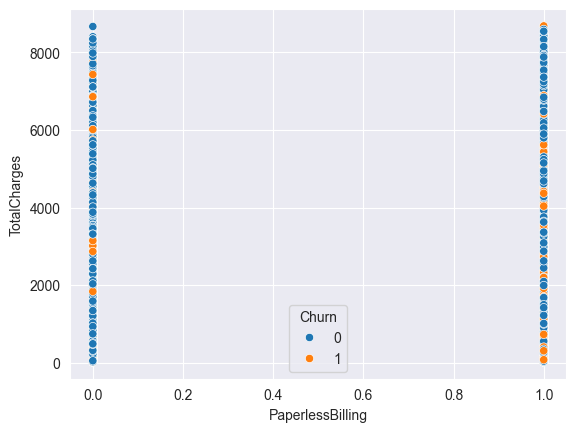

In [21]:
sns.scatterplot(data=df,x="PaperlessBilling",y="TotalCharges",hue="Churn")
plt.show()

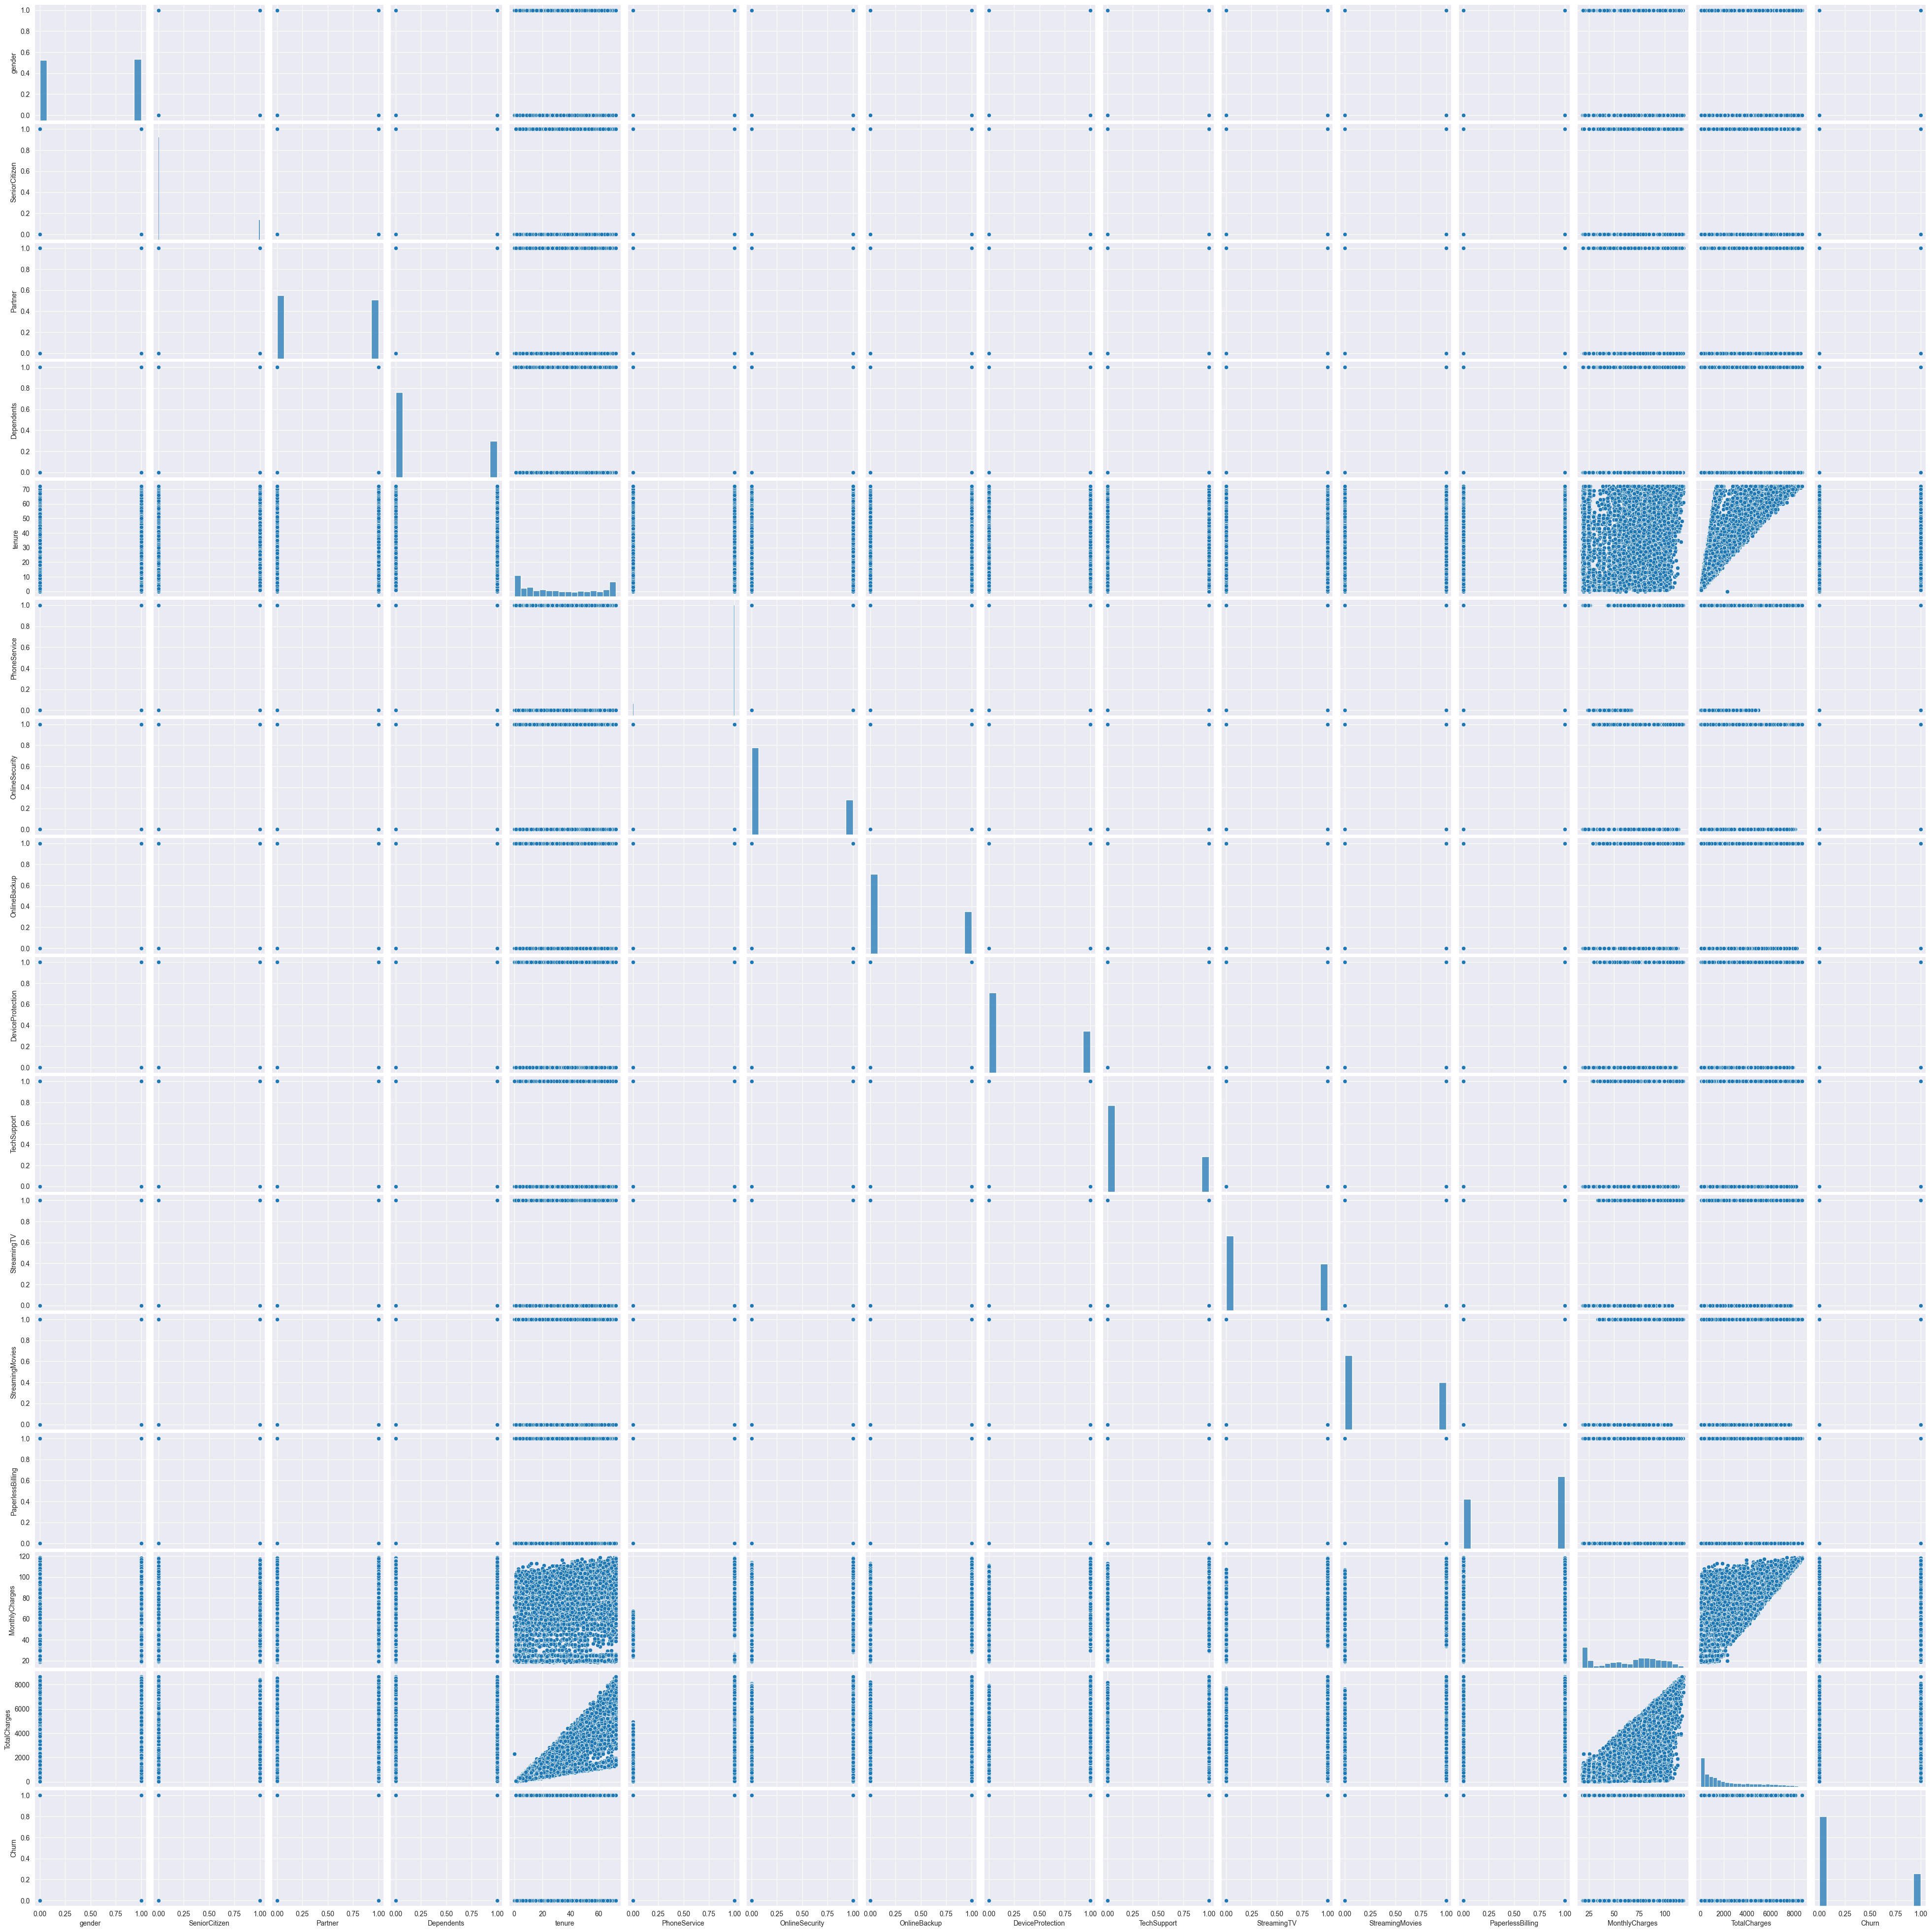

In [22]:
sns.pairplot(df)
plt.show()

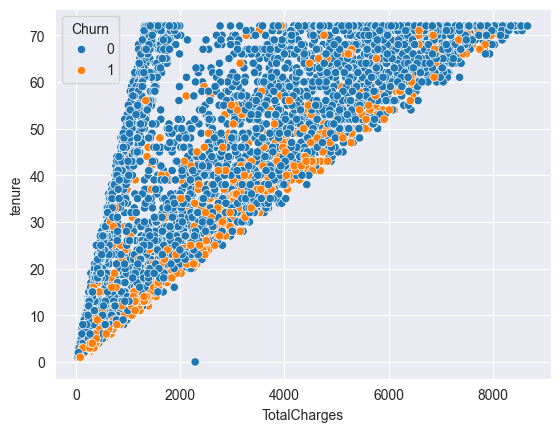

In [23]:
sns.scatterplot(data=df, x="TotalCharges", y="tenure", hue="Churn")
plt.show()

In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
xgb=XGBClassifier()

In [29]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
y_pred=xgb.predict(X_test)

In [31]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[919 193]
 [104 193]]
accuracy score:  0.7892122072391767
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      1112
           1       0.50      0.65      0.57       297

    accuracy                           0.79      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.81      0.79      0.80      1409



In [32]:
#lets try hyperparameter tunning
params = {
        "n_estimators" : [100, 200, 300],
        "learning_rate" : [0.01, 0.1],
        "max_depth" : [5,8,12],
        "colsample_bytree" : [ 0.5, 0.8, 1]
}

In [33]:
grid_search= GridSearchCV(estimator=xgb,param_grid=params,cv=5,verbose=1,n_jobs=-1)

In [34]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.5, 0.8, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [35]:
grid_search.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.01,
 'max_depth': 5,
 'n_estimators': 300}

In [36]:
y_pred_withparamer = grid_search.predict(X_test)

In [37]:
print("confusion matrix: \n", confusion_matrix(y_pred_withparamer, y_test))
print("accuracy score: ", accuracy_score(y_pred_withparamer, y_test))
print(classification_report(y_pred_withparamer, y_test))

confusion matrix: 
 [[946 212]
 [ 77 174]]
accuracy score:  0.794889992902768
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1158
           1       0.45      0.69      0.55       251

    accuracy                           0.79      1409
   macro avg       0.69      0.76      0.71      1409
weighted avg       0.84      0.79      0.81      1409



In [38]:
importances= xgb.feature_importances_
importance_df=pd.DataFrame( {'Feature': X.columns ,'Importance':importances})
importance_df=importance_df.sort_values(by='Importance',ascending=False).head(5)

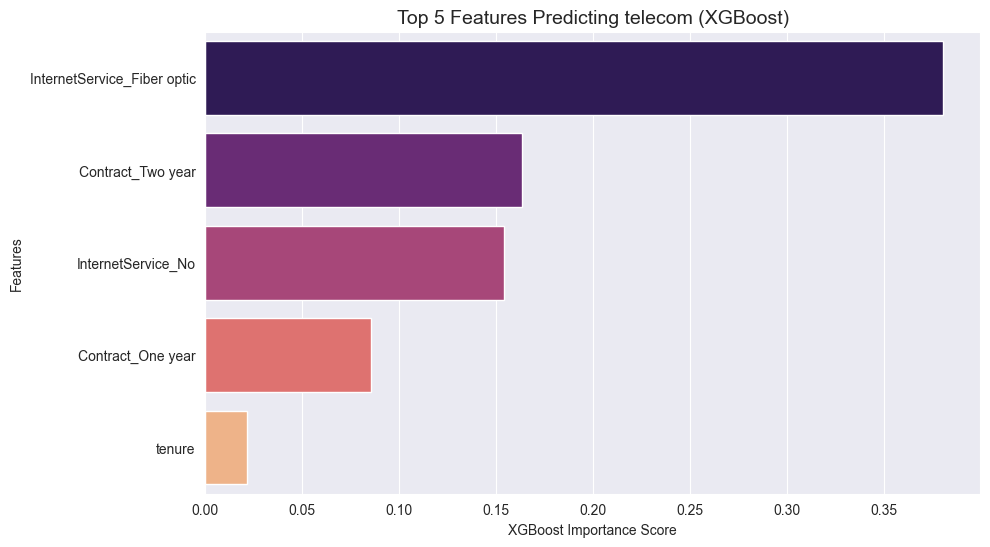

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance_df,palette='magma', hue='Feature', legend=False)
plt.title('Top 5 Features Predicting telecom (XGBoost)', fontsize=14)
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.show()